In [11]:
from hello.deepWorld.models.wav2vec2_hf import AutoModelForAudioClassification,feature_extractor,get_wav2vec_model,preprocess_function,BASE_TRAINING_ARGUMENTS,compute_metrics
from hello.dataWorld.dataset.pangramDataLoaders import SpeakerSignalDataset
from transformers import TrainingArguments
from transformers.trainer import Trainer 

In [2]:
DATA_PATH_TRAIN="../data/data_flat/sp_audio_dataset_mq_trim25/train"
DATA_PATH_VAL="../data/data_flat/sp_audio_dataset_mq_trim25/val"
RES_PATH="../results/models_ckpt/wav2vec2"
LOG_PATH="../results/models_log/wav2vec2"

In [3]:
train=SpeakerSignalDataset(DATA_PATH_TRAIN,signalType="wav",prepro_func=preprocess_function)
val=SpeakerSignalDataset(DATA_PATH_VAL,signalType="wav",prepro_func=preprocess_function)

In [4]:

model=get_wav2vec_model(len(train.id2label),train.label2id,train.id2label)

c:\Users\emman\anaconda3\envs\datascience\lib\site-packages\transformers\configuration_utils.py:369: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base were not used when initializing Wav2Vec2ForSequenceClassification: ['project_q.weight', 'quantizer.weight_proj.weight', 'project_hid.bias', 'quantizer.codevectors', 'project_hid.weight', 'project_q.bias', 'quantizer.weight_proj.bias']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing 

In [5]:
train_args=TrainingArguments(**BASE_TRAINING_ARGUMENTS)

train_args.output_dir=RES_PATH
train_args.logging_dir=LOG_PATH
train_args.per_device_eval_batch_size=4
train_args.per_device_train_batch_size=4
train_args.max_steps=100
train_args.dataloader_num_workers=1


trainer=Trainer(
    model=model,
    args=train_args,
    train_dataset=train,
    eval_dataset=val,
    compute_metrics=compute_metrics
)



max_steps is given, it will override any value given in num_train_epochs


In [6]:
trainer.train()

c:\Users\emman\anaconda3\envs\datascience\lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 341
  Num Epochs = 2
  Instantaneous batch size per device = 4
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 1
  Total optimization steps = 100
 10%|█         | 10/100 [01:44<12:58,  8.65s/it]***** Running Evaluation *****
  Num examples = 147
  Batch size = 4


{'loss': 2.0837, 'learning_rate': 2.7000000000000002e-05, 'epoch': 0.12}


                                                
 10%|█         | 10/100 [03:04<12:58,  8.65s/it]Saving model checkpoint to ../results/models_ckpt/wav2vec2\checkpoint-10
Configuration saved in ../results/models_ckpt/wav2vec2\checkpoint-10\config.json


{'eval_loss': 2.0670969486236572, 'eval_accuracy': 0.1564625850340136, 'eval_runtime': 79.4513, 'eval_samples_per_second': 1.85, 'eval_steps_per_second': 0.466, 'epoch': 0.12}


Model weights saved in ../results/models_ckpt/wav2vec2\checkpoint-10\pytorch_model.bin
 20%|██        | 20/100 [04:46<11:04,  8.31s/it]  ***** Running Evaluation *****
  Num examples = 147
  Batch size = 4


...

                                                 
100%|██████████| 100/100 [30:56<00:00,  8.93s/it]Saving model checkpoint to ../results/models_ckpt/wav2vec2\checkpoint-100
Configuration saved in ../results/models_ckpt/wav2vec2\checkpoint-100\config.json


{'eval_loss': 1.966103434562683, 'eval_accuracy': 0.42857142857142855, 'eval_runtime': 76.1301, 'eval_samples_per_second': 1.931, 'eval_steps_per_second': 0.486, 'epoch': 1.16}


Model weights saved in ../results/models_ckpt/wav2vec2\checkpoint-100\pytorch_model.bin
Deleting older checkpoint [..\results\models_ckpt\wav2vec2\checkpoint-80] due to args.save_total_limit


Training completed. Do not forget to share your model on huggingface.co/models =)


100%|██████████| 100/100 [31:02<00:00, 18.62s/it]

{'train_runtime': 1862.4824, 'train_samples_per_second': 0.215, 'train_steps_per_second': 0.054, 'train_loss': 2.0184313583374025, 'epoch': 1.16}


TrainOutput(global_step=100, training_loss=2.0184313583374025, metrics={'train_runtime': 1862.4824, 'train_samples_per_second': 0.215, 'train_steps_per_second': 0.054, 'train_loss': 2.0184313583374025, 'epoch': 1.16})

In [10]:
import torch
predicted=torch.argmax(model(val[100]["input_values"].unsqueeze(0)).logits.detach()).item()
train.id2label[predicted],val[100]["label"]

('giorgia5', tensor(3))

In [ ]:
model2=AutoModelForAudioClassification.from_pretrained("../results/models_ckpt/wav2vec2\checkpoint-100\\")


I'm listening...
Sound detected and recorded.


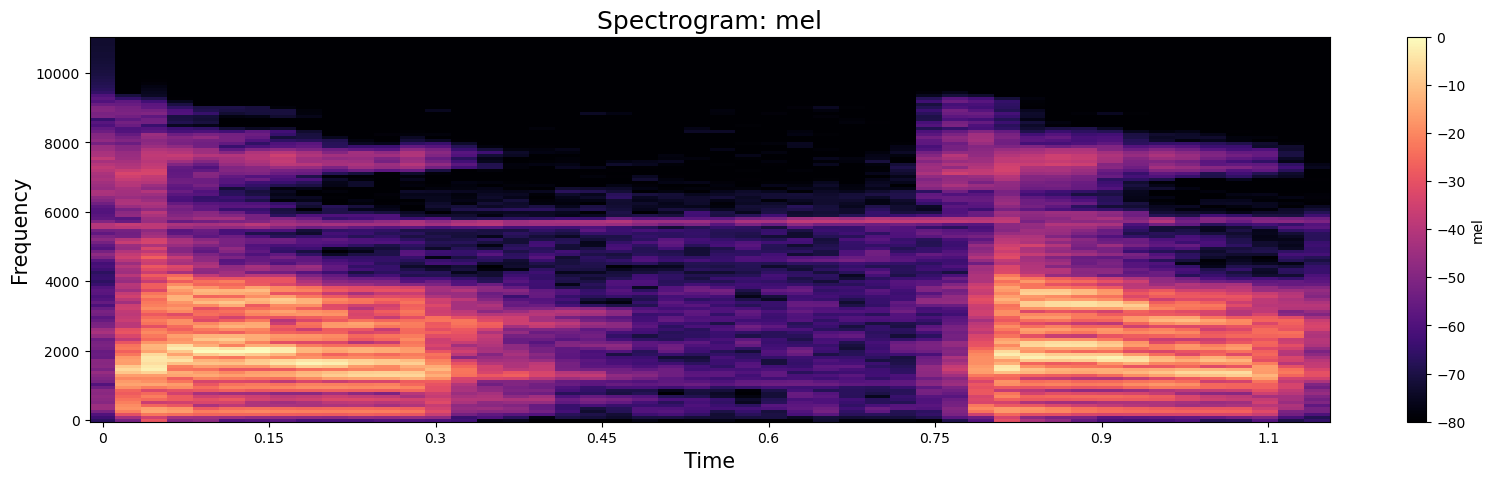

*************
Speaker: alessandro0
*************
I'm listening...
Sound detected and recorded.


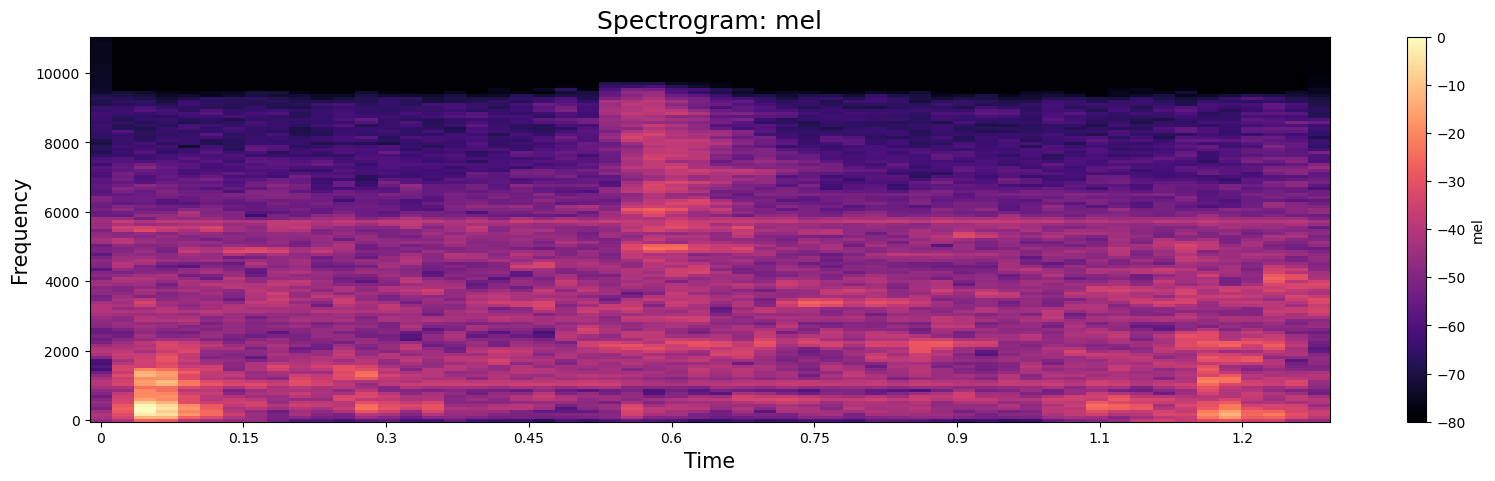

*************
Speaker: anna2
*************
I'm listening...
Sound detected and recorded.


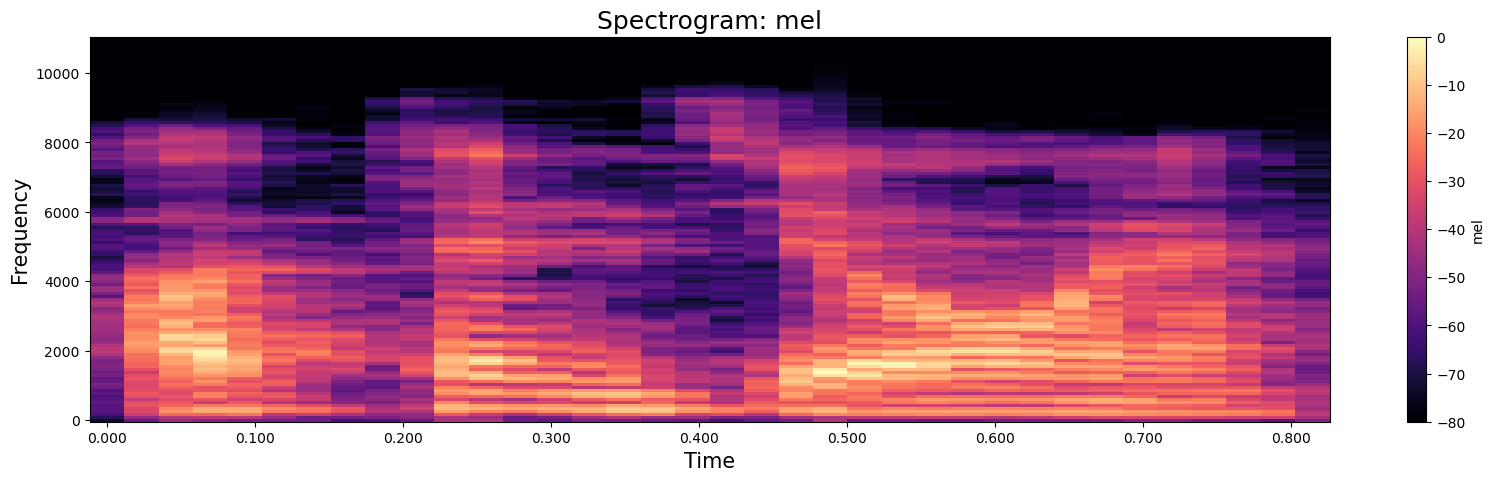

*************
Speaker: alessandro0
*************
I'm listening...
Sound detected and recorded.


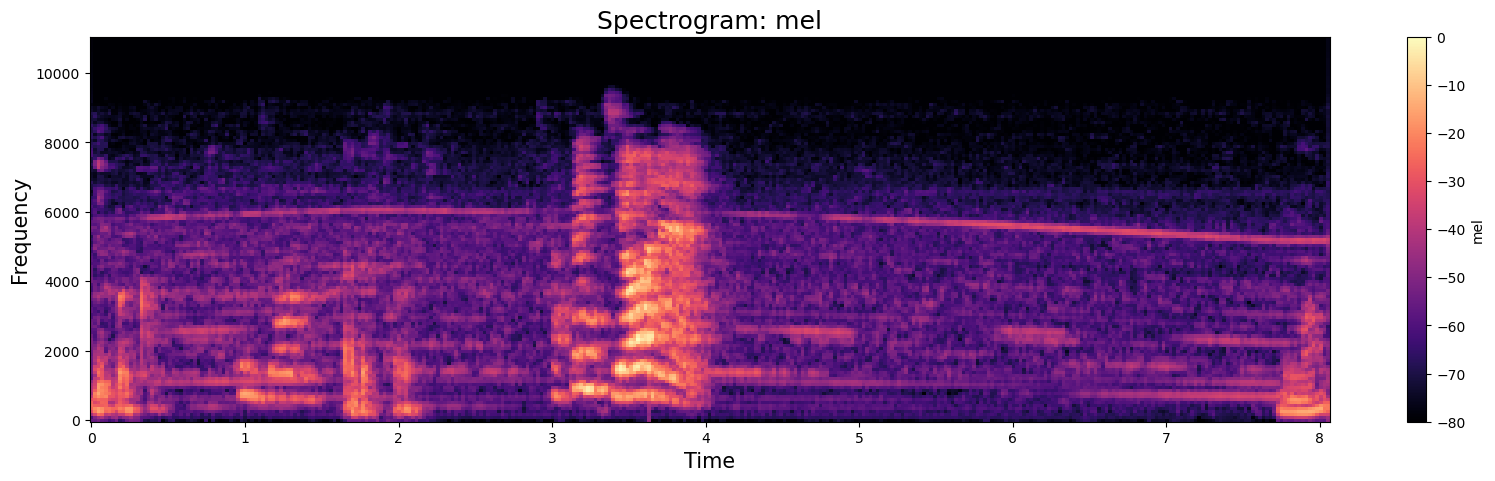

*************
Speaker: anna2
*************
I'm listening...
Sound detected and recorded.


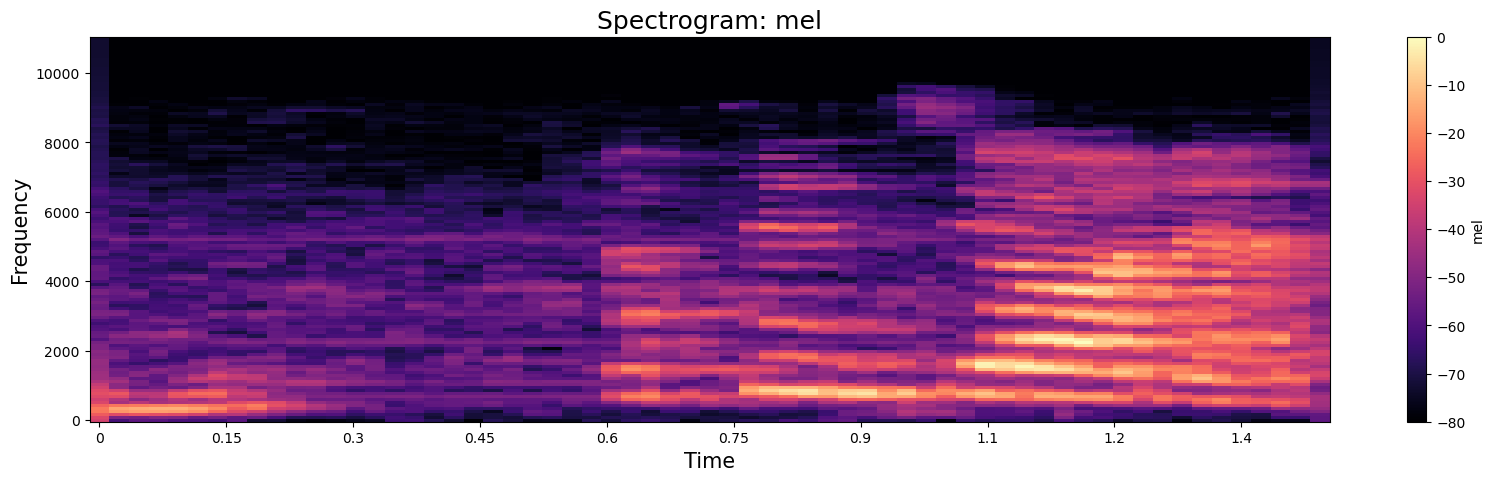

*************
Speaker: ilaria3
*************
I'm listening...
Sound detected and recorded.


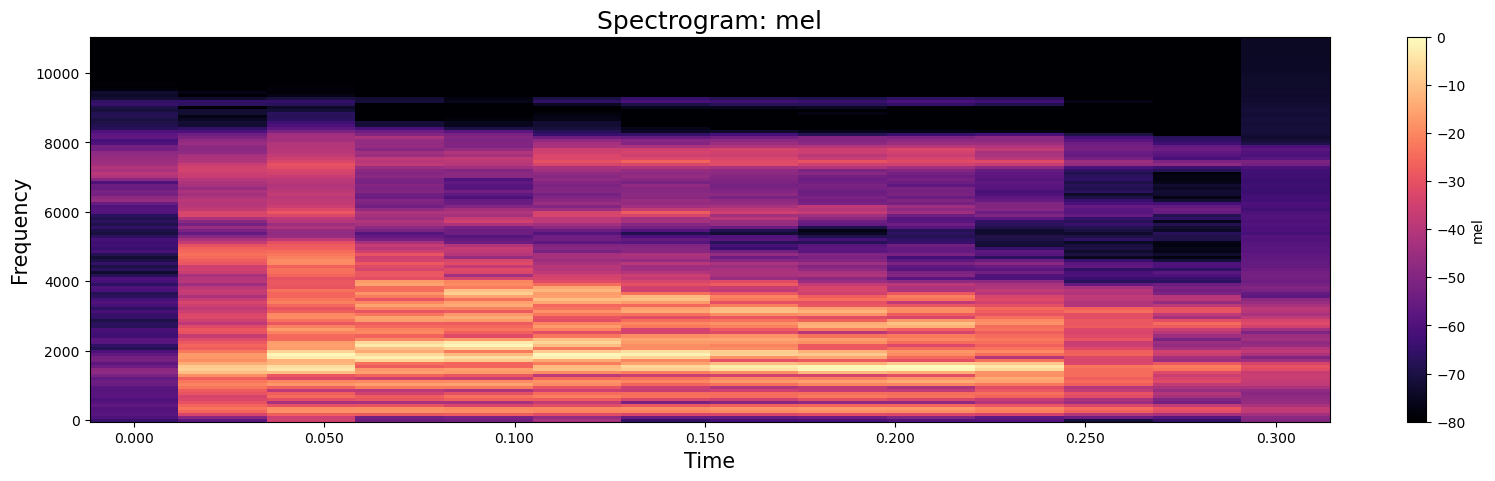

*************
Speaker: alessandro0
*************
I'm listening...
Sound detected and recorded.


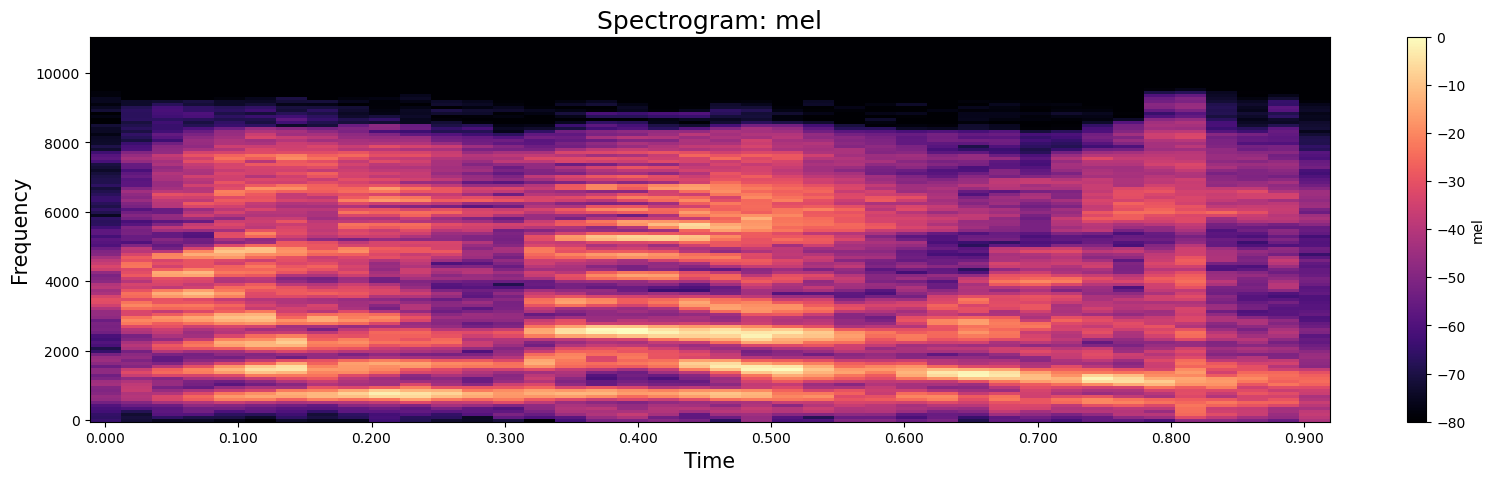

*************
Speaker: anna2
*************
I'm listening...
Sound detected and recorded.


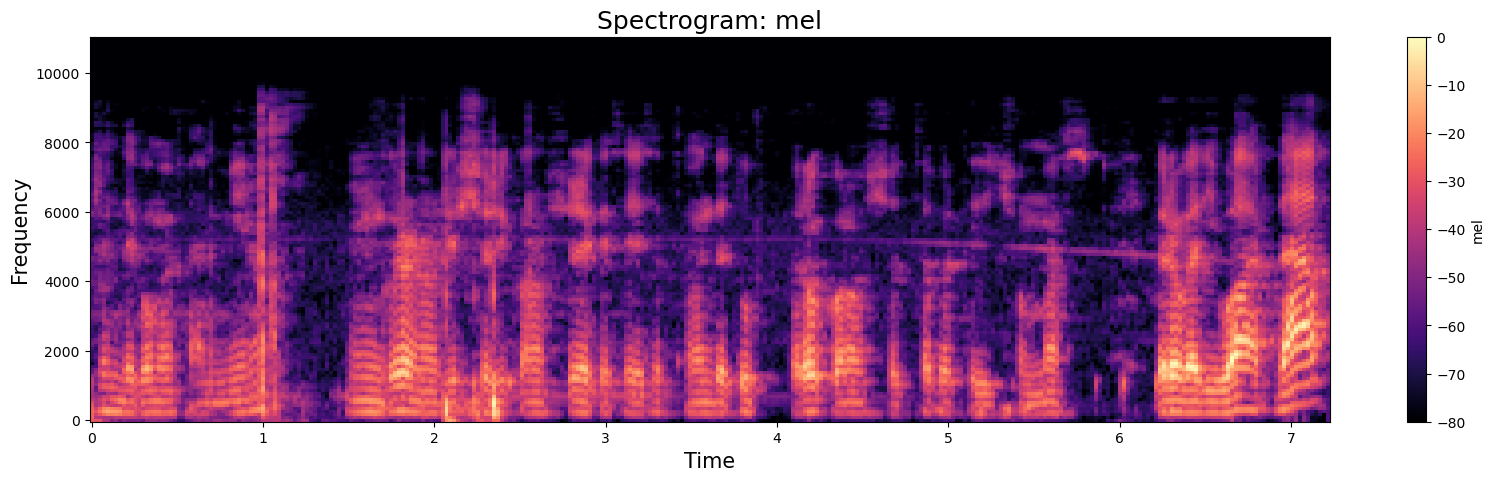

*************
Speaker: alessandro0
*************
I'm listening...
Sound detected and recorded.


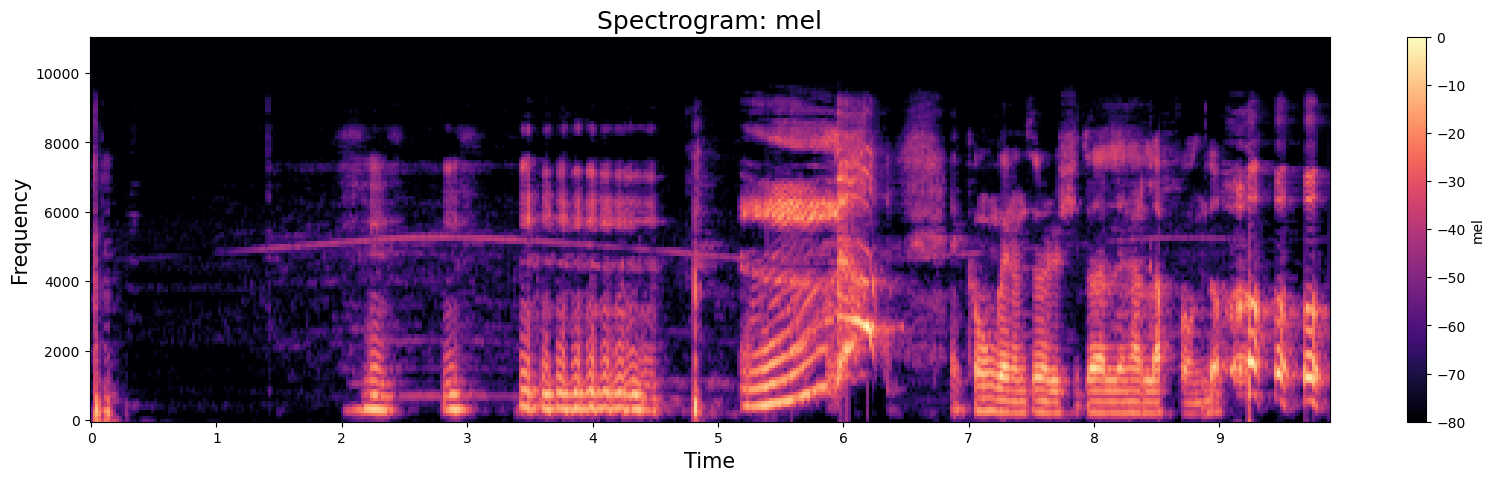

*************
Speaker: giorgia5
*************
I'm listening...
Sound detected and recorded.


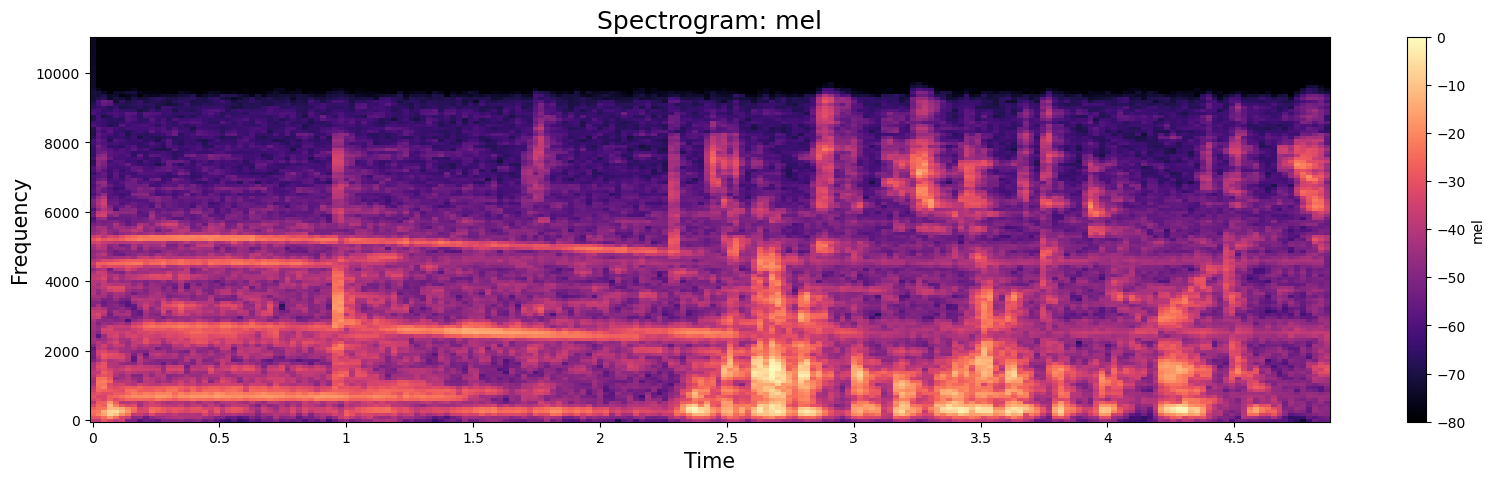

*************
Speaker: claudia4
*************
I'm listening...
Sound detected and recorded.


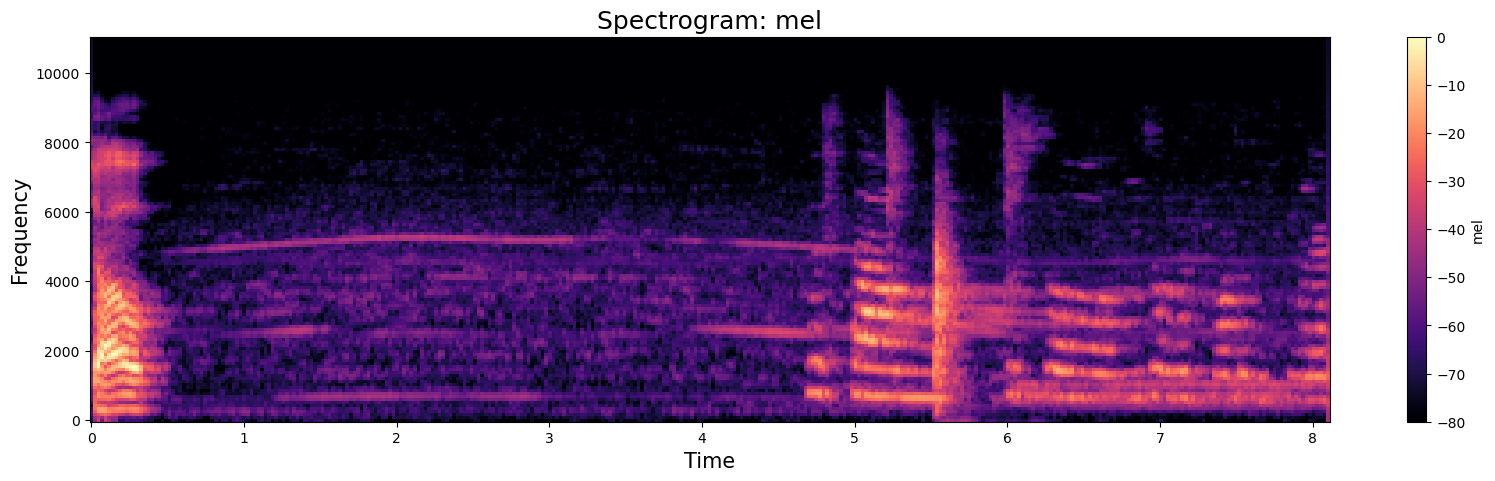

*************
Speaker: claudia4
*************
I'm listening...
Sound detected and recorded.


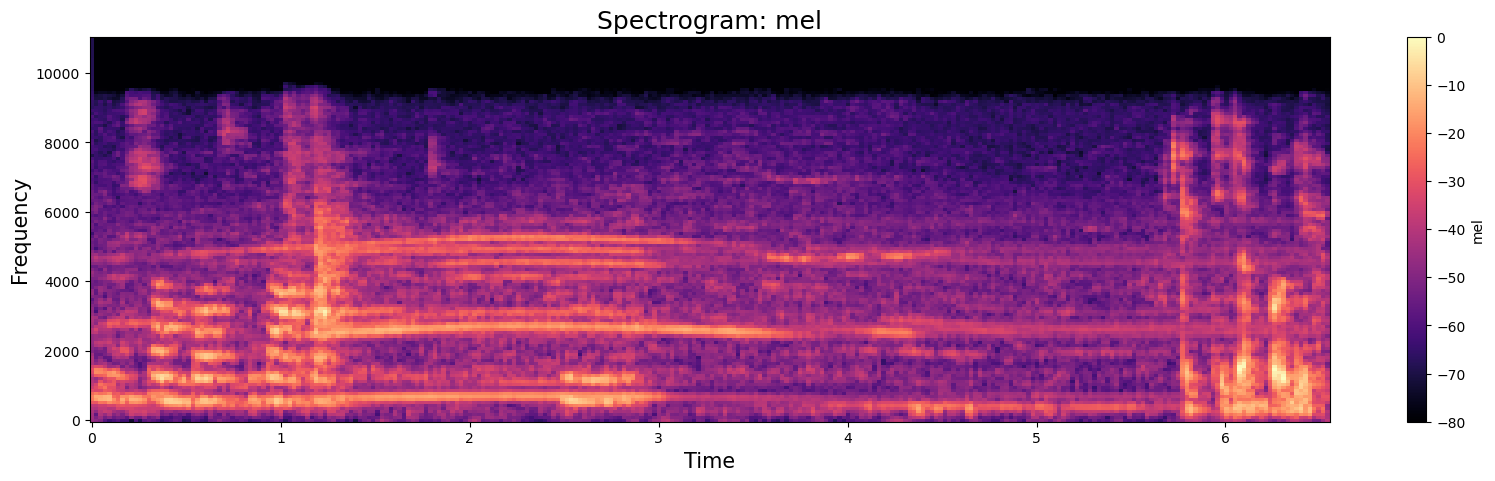

*************
Speaker: ilaria3
*************
I'm listening...
Sound detected and recorded.


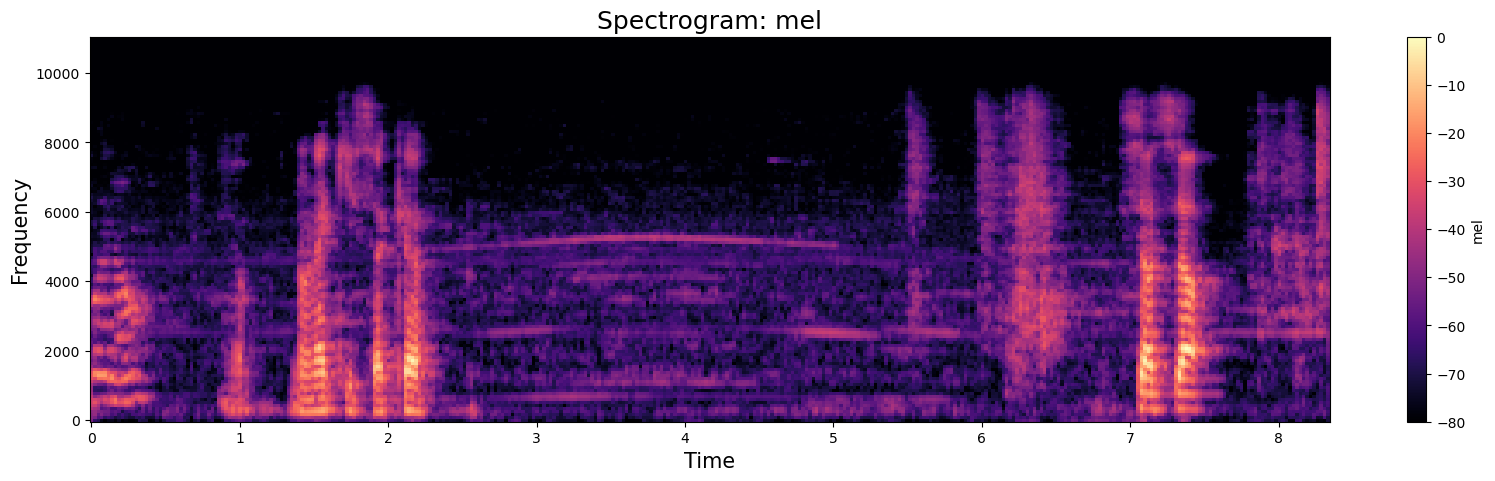

*************
Speaker: ilaria3
*************
I'm listening...
Sound detected and recorded.


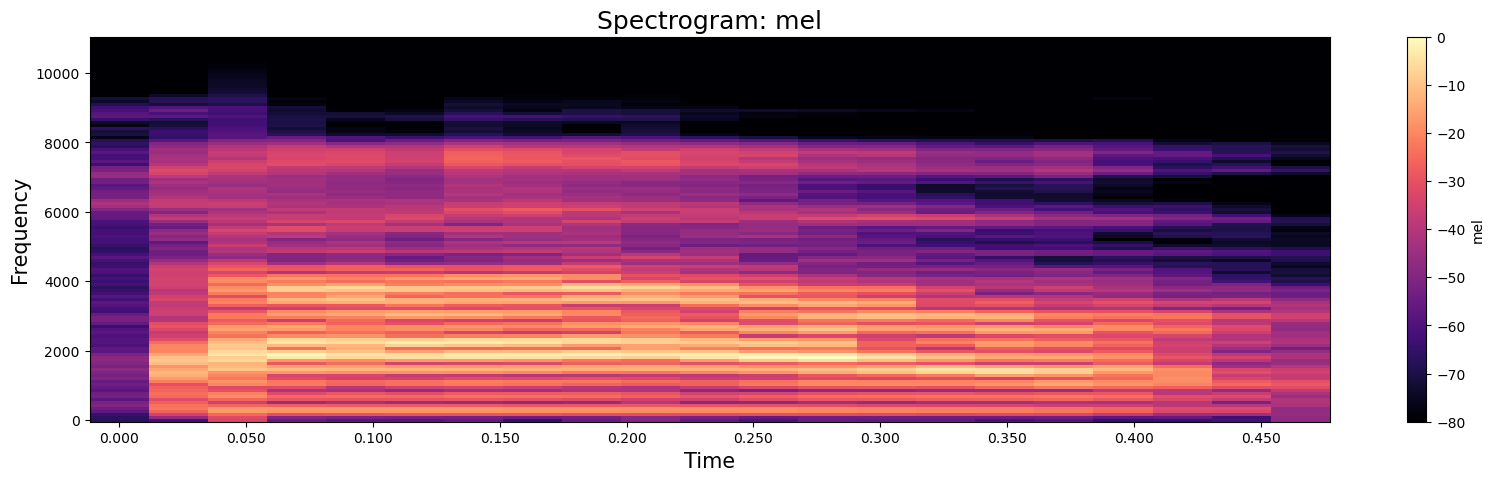

*************
Speaker: alessandro0
*************
I'm listening...
Sound detected and recorded.


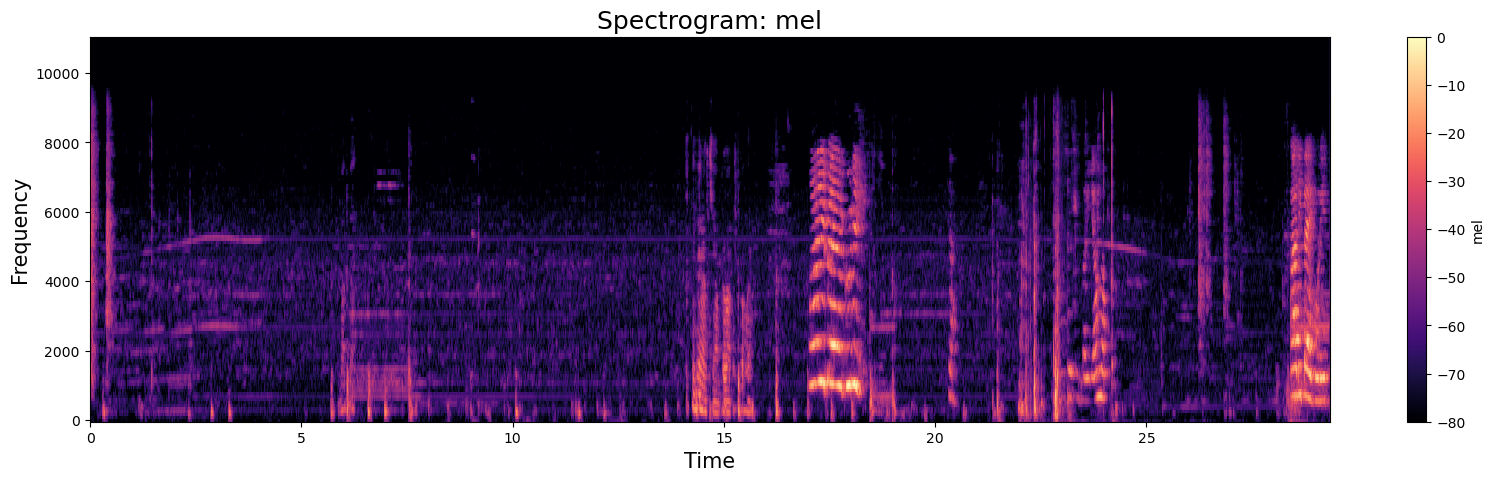

*************
Speaker: anna2
*************
I'm listening...
Sound detected and recorded.


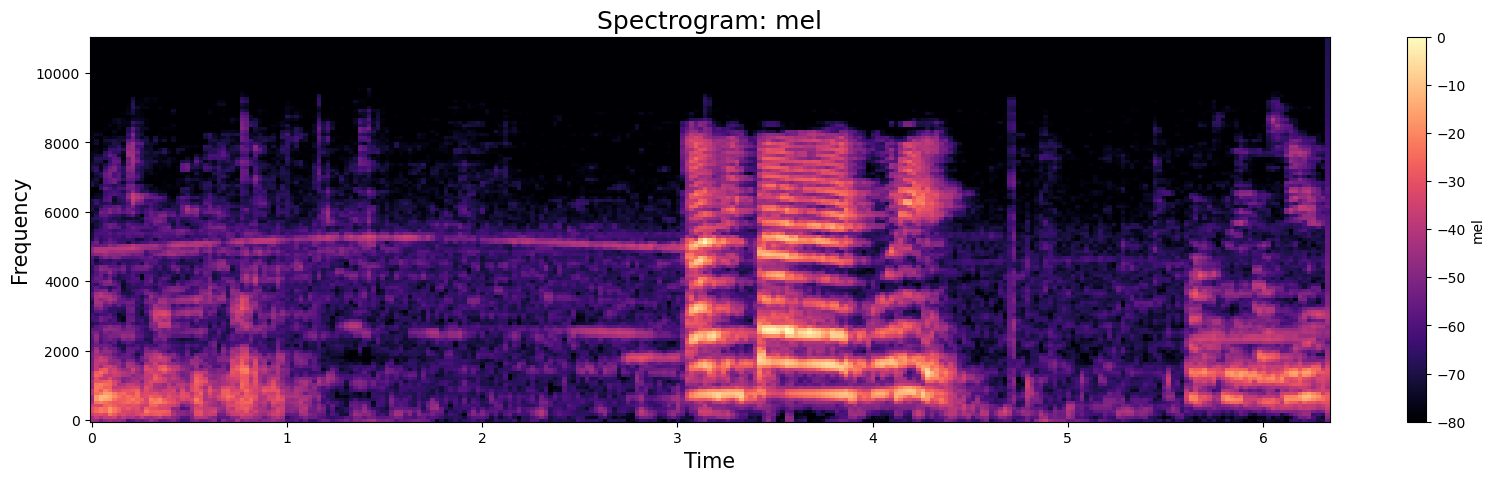

*************
Speaker: anna2
*************
I'm listening...


KeyboardInterrupt: 

In [24]:
from hello.dataWorld.audioTools import listen,librosa,audio_to_image,plot_wav,plt,plot_spectr,get_spectr
from torch import tensor


def prepare_input(audioSig,top_db=25,nfft=4400,w=128,h=128,imgTo=lambda i:preprocess_function(i)):
    audioSigTrim,_ = librosa.effects.trim(y=audioSig[0],top_db=top_db)
    #plot_wav(audioSig)
    plt.show()
    audioSig=(audioSigTrim,audioSig[1])
    #img=audio_to_image(audioSig,nfft,scale="mel",width=w,height=h)[1]
    #highres=audio_to_image(audioSig,nfft,scale="mel",width=1024,height=1024)[1]
    #printAudio(audioSig[0],rate=audioSig[1])
    #imshow(highres)
    #plot_wav(audioSig)
    inputs = feature_extractor(
        audioSig[0], sampling_rate=feature_extractor.sampling_rate, max_length=16000, truncation=True
    )

   



    plot_spectr(get_spectr(audioSig,n_fft=nfft,scale="mel"),sr=audioSig[1],scale_name="mel")
    plt.show()
    return inputs["input_values"][0]

def predict(input,model):
    pre_in=prepare_input(input,top_db=20)
    out=model(tensor(pre_in).unsqueeze(0))
    predicted=torch.argmax(out.logits.detach()).item()
    out_label=train.id2label[predicted]
    return out_label

listen(callable_fn=lambda v:print(f"*************\nSpeaker: {predict(v,model)}\n*************"),sample_rate=22000)